In [41]:
# Cell 1 — Imports and helpers
import os, json
import pandas as pd
import matplotlib.pyplot as plt
from utils_analysis import load_loadtrace_for_run

def per_second_rps_effective(events: pd.DataFrame) -> pd.DataFrame:
    """Compute per-second rps_effective from arrival events."""
    if events is None or events.empty:
        return pd.DataFrame(columns=["second_ts", "rps_effective"])
    df = events.copy()
    df = df[df.get("event") == "arrival"]
    if df.empty or "rps_effective" not in df.columns:
        return pd.DataFrame(columns=["second_ts", "rps_effective"])
    df["ts"] = pd.to_datetime(df["ts"], errors="coerce")
    df["second_ts"] = df["ts"].dt.floor("S")
    per_sec = df.groupby("second_ts", as_index=False)["rps_effective"].last()
    return per_sec.sort_values("second_ts").reset_index(drop=True)

def plot_rps_effective(per_sec: pd.DataFrame, title: str):
    if per_sec is None or per_sec.empty:
        print(f"[skip] {title}: no rps_effective found")
        return
    plt.figure(figsize=(9, 4))
    plt.plot(per_sec["second_ts"], per_sec["rps_effective"], label="rps_effective")
    plt.title(title)
    plt.xlabel("Time (s)")
    plt.ylabel("RPS (effective)")
    plt.grid(True, linestyle="--", alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


In [42]:
# Cell 2 — Configuration: where and which experiments
BASE_DIR = "/home/saeid/llm-lb/results"

EXPERIMENTS = [
    ("least-queue-batching", "197"),
    ("rr-batching", "197"),
    ("pull-batching", "197"),
]


In [43]:
# Cell 3 — Load traces for all experiments
infos = {}
events_by_exp = {}

for method, run_id in EXPERIMENTS:
    info = load_loadtrace_for_run(BASE_DIR, method, run_id)
    infos[(method, run_id)] = info
    events_by_exp[(method, run_id)] = info["events"]
    print(f"[{method}/{run_id}] Loaded:", info["path"])
    ev = info["events"]
    print(f"[{method}/{run_id}] Events shape:", ev.shape)
    if not ev.empty:
        display(ev.head(5))


[least-queue-batching/197] Loaded: /home/saeid/llm-lb/results/least-queue-batching/197/load.jsonl
[least-queue-batching/197] Events shape: (1002, 16)


,ts,router_mode,event,pattern,seed,warmup_s,effective_start_ts,phase,idx,uid,second,rps_effective,planned_at,woke_at,enq_at,sent
0,2025-11-10 18:19:36.229565+00:00,least-queue-batching,start,rand,12345.0,0.0,1.762799e+09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-11-10 18:19:36.297688+00:00,least-queue-batching,arrival,rand,NaN,NaN,NaN,main,1.0,0-1,0.0,7.0,1.762799e+09,1.762799e+09,1.762799e+09,NaN
2,2025-11-10 18:19:36.441302+00:00,least-queue-batching,arrival,rand,NaN,NaN,NaN,main,2.0,0-2,0.0,7.0,1.762799e+09,1.762799e+09,1.762799e+09,NaN
3,2025-11-10 18:19:36.583294+00:00,least-queue-batching,arrival,rand,NaN,NaN,NaN,main,3.0,0-3,0.0,7.0,1.762799e+09,1.762799e+09,1.762799e+09,NaN
4,2025-11-10 18:19:36.727175+00:00,least-queue-batching,arrival,rand,NaN,NaN,NaN,main,4.0,0-4,0.0,7.0,1.762799e+09,1.762799e+09,1.762799e+09,NaN


[rr-batching/197] Loaded: /home/saeid/llm-lb/results/rr-batching/197/load.jsonl
[rr-batching/197] Events shape: (1002, 16)


,ts,router_mode,event,pattern,seed,warmup_s,effective_start_ts,phase,idx,uid,second,rps_effective,planned_at,woke_at,enq_at,sent
0,2025-11-10 18:11:00.008552+00:00,rr-batching,start,rand,12345.0,0.0,1.762798e+09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-11-10 18:11:00.076958+00:00,rr-batching,arrival,rand,NaN,NaN,NaN,main,1.0,0-1,0.0,7.0,1.762798e+09,1.762798e+09,1.762798e+09,NaN
2,2025-11-10 18:11:00.220028+00:00,rr-batching,arrival,rand,NaN,NaN,NaN,main,2.0,0-2,0.0,7.0,1.762798e+09,1.762798e+09,1.762798e+09,NaN
3,2025-11-10 18:11:00.363816+00:00,rr-batching,arrival,rand,NaN,NaN,NaN,main,3.0,0-3,0.0,7.0,1.762798e+09,1.762798e+09,1.762798e+09,NaN
4,2025-11-10 18:11:00.505489+00:00,rr-batching,arrival,rand,NaN,NaN,NaN,main,4.0,0-4,0.0,7.0,1.762798e+09,1.762798e+09,1.762798e+09,NaN


[pull-batching/197] Loaded: /home/saeid/llm-lb/results/pull-batching/197/load.jsonl
[pull-batching/197] Events shape: (1002, 16)


,ts,router_mode,event,pattern,seed,warmup_s,effective_start_ts,phase,idx,uid,second,rps_effective,planned_at,woke_at,enq_at,sent
0,2025-11-10 18:01:59.926142+00:00,pull-batching,start,rand,12345.0,0.0,1.762798e+09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-11-10 18:01:59.990603+00:00,pull-batching,arrival,rand,NaN,NaN,NaN,main,1.0,0-1,0.0,7.0,1.762798e+09,1.762798e+09,1.762798e+09,NaN
2,2025-11-10 18:02:00.134053+00:00,pull-batching,arrival,rand,NaN,NaN,NaN,main,2.0,0-2,0.0,7.0,1.762798e+09,1.762798e+09,1.762798e+09,NaN
3,2025-11-10 18:02:00.278375+00:00,pull-batching,arrival,rand,NaN,NaN,NaN,main,3.0,0-3,0.0,7.0,1.762798e+09,1.762798e+09,1.762798e+09,NaN
4,2025-11-10 18:02:00.419931+00:00,pull-batching,arrival,rand,NaN,NaN,NaN,main,4.0,0-4,0.0,7.0,1.762798e+09,1.762798e+09,1.762798e+09,NaN


/tmp/ipykernel_2940422/2202784987.py:16: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  df["second_ts"] = df["ts"].dt.floor("S")


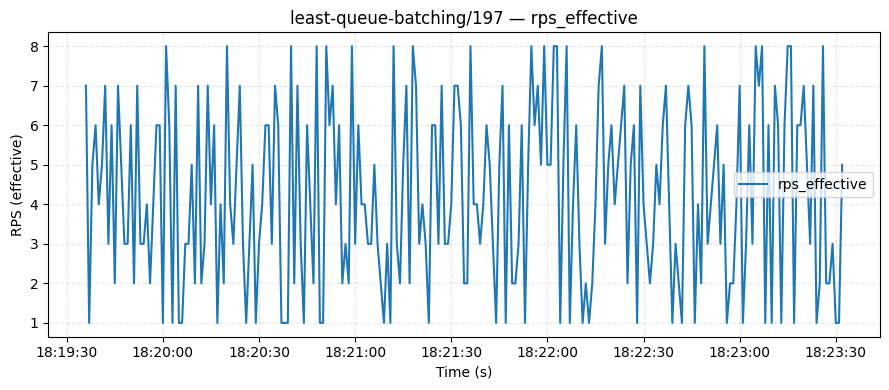

/tmp/ipykernel_2940422/2202784987.py:16: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  df["second_ts"] = df["ts"].dt.floor("S")


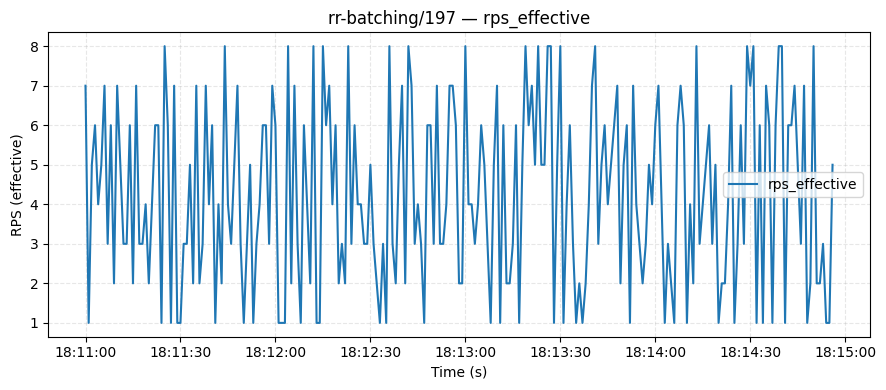

/tmp/ipykernel_2940422/2202784987.py:16: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  df["second_ts"] = df["ts"].dt.floor("S")


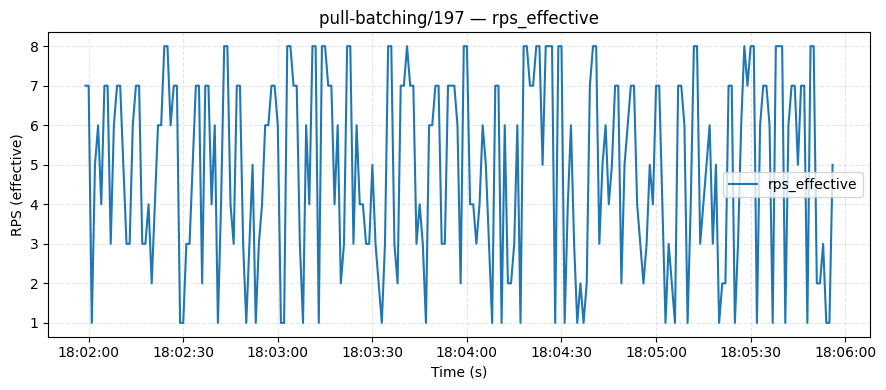

In [44]:
# Cell 4 — Compute per-second rps_effective and plot each separately
rps_eff_by_exp = {}

for method, run_id in EXPERIMENTS:
    ev = events_by_exp[(method, run_id)]
    per_sec = per_second_rps_effective(ev)
    rps_eff_by_exp[(method, run_id)] = per_sec
    plot_rps_effective(per_sec, f"{method}/{run_id} — rps_effective")


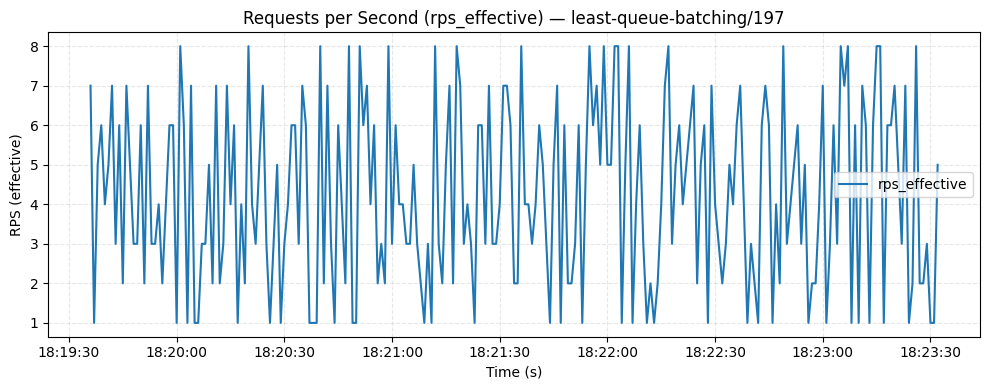

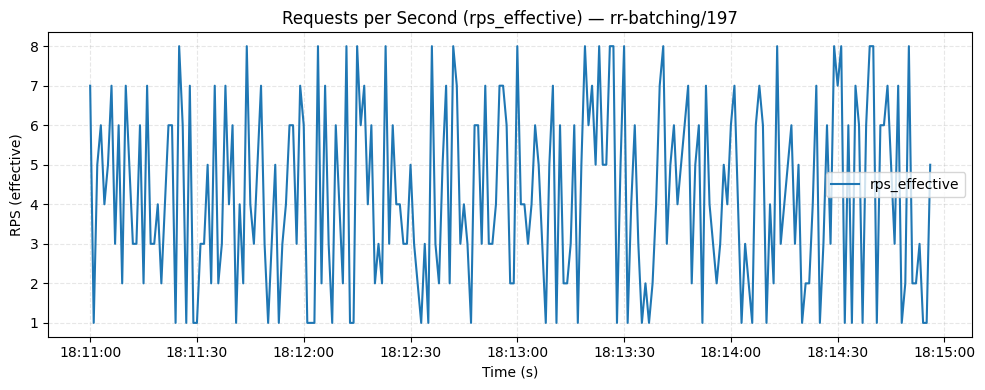

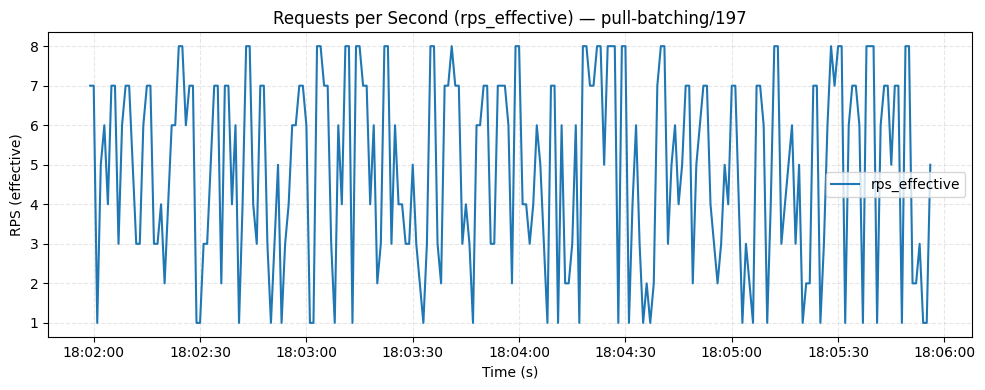

In [46]:
# Cell 5 — Separate figure for each experiment (not combined)
for (method, run_id), per_sec in rps_eff_by_exp.items():
    if per_sec is None or per_sec.empty:
        print(f"[skip] {method}/{run_id}: no rps_effective data")
        continue

    plt.figure(figsize=(10, 4))
    plt.plot(per_sec["second_ts"], per_sec["rps_effective"], label="rps_effective")
    plt.title(f"Requests per Second (rps_effective) — {method}/{run_id}")
    plt.xlabel("Time (s)")
    plt.ylabel("RPS (effective)")
    plt.grid(True, linestyle="--", alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()
